# MainChecks — half-open occupancy & same-day handoff

Quick checks for planner set-packing: **occupancy is half-open** `[plant_day, plant_day + tile_free_age)`; **ops include the free day** (HARVEST/DIG then PLANT).

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from agent import rollouts
from agent.planner import _build_candidates, solve_plan

with open(ROOT / "data" / "crop_rollouts.json", encoding="utf-8") as f:
    _crop_data = json.load(f)["crops"]

PLAN_HORIZON = rollouts.PLAN_HORIZON   # packing grid + plant_day cap (days 0..27)
OPS_HORIZON = rollouts.SEASON_DAYS     # farmer ops through day 29; day 29 ≈ sell
NUM_TILES = 9
PRICES = {c: _crop_data[c]["base_price"] for c in rollouts.crop_names()}
print(f"plan={PLAN_HORIZON} ops={OPS_HORIZON}")

In [2]:
# --- half-open semantics (rollouts) ---

def assert_half_open(crop: str, plant_day: int = 0):
    covered = rollouts.covered_days(crop, plant_day, PLAN_HORIZON)
    ops = rollouts.ops_by_calendar_day(crop, plant_day, OPS_HORIZON)
    free = plant_day + rollouts.tile_free_age(crop)
    assert free not in covered, f"{crop}: free day {free} must not be in covered"
    assert free in ops, f"{crop}: free day {free} must be in ops"
    print(f"{crop:10} covered={sorted(covered)}  ops-only={free} ({ops[free]} ops)")

for c in rollouts.crop_names():
    assert_half_open(c)

a = next(s for s in _build_candidates({0}, 0, PLAN_HORIZON, OPS_HORIZON, PRICES) if s["crop"] == "WHEAT" and s["plant_day"] == 0)
b = next(s for s in _build_candidates({0}, 0, PLAN_HORIZON, OPS_HORIZON, PRICES) if s["crop"] == "WHEAT" and s["plant_day"] == 4)
assert not (a["subset"] & b["subset"]), "handoff day should not double-book occupancy"
assert a["ops_by_day"][4] and b["ops_by_day"][4], "both lifecycles still have ops on day 4"
print("handoff day 4 ops:", a["ops_by_day"][4], "+", b["ops_by_day"][4], "=", a["ops_by_day"][4] + b["ops_by_day"][4])

WHEAT      covered=[0, 1, 2, 3]  ops-only=4 (2 ops)
CARROT     covered=[0, 1, 2]  ops-only=3 (2 ops)
TOMATO     covered=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  ops-only=11 (3 ops)
MELON      covered=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  ops-only=10 (2 ops)
STRAWBERRY covered=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]  ops-only=16 (3 ops)
handoff day 4 ops: 2 + 2 = 4


In [3]:
# --- Gantt (from FarmerOnly, extended for half-open + ops tail) ---

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT":      {"color": "#e8c84a", "hatch": "///"},
    "CARROT":     {"color": "#e8913a", "hatch": "+++"},
    "TOMATO":     {"color": "#8bc34a", "hatch": "xxx"},
    "MELON":      {"color": "#2e7d32", "hatch": "ooo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": "..."},
}


def _enrich(item: dict) -> dict:
    """Ensure subset + ops_by_day on a candidate or placement dict."""
    tile = item["tile"]
    plant_day = item["plant_day"]
    crop = item["crop"]
    subset = item.get("subset")
    if subset is None:
        subset = {(tile, d) for d in rollouts.covered_days(crop, plant_day, PLAN_HORIZON)}
    ops = item.get("ops_by_day")
    if ops is None:
        ops = rollouts.ops_by_calendar_day(crop, plant_day, OPS_HORIZON)
    return {**item, "subset": subset, "ops_by_day": ops}


def gantt(selected, horizon=OPS_HORIZON, title="Selected plantings (half-open occupancy + ops tail)"):
    items = [_enrich(s) for s in selected]
    fig, ax = plt.subplots(figsize=(14, max(3, 0.6 * NUM_TILES + 1)))

    for s in items:
        days = sorted(d for t, d in s["subset"] if t == s["tile"])
        if not days:
            continue
        start, end = days[0], days[-1] + 1  # half-open bar
        style = CROP_STYLE.get(s["crop"], {"color": "#999999", "hatch": ""})
        ax.barh(
            y=s["tile"],
            width=end - start,
            left=start,
            height=0.55,
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="#333333",
            linewidth=0.8,
            alpha=0.95,
        )
        label = f"{s['crop'][:3]}{s['plant_day']}"
        ax.text(start + 0.15, s["tile"], label, va="center", fontsize=7, color="#111")

        # ops-only tail: calendar days with ops but not in occupancy subset
        occ_days = set(days)
        for cal, n_ops in s["ops_by_day"].items():
            if cal not in occ_days and n_ops:
                ax.barh(
                    y=s["tile"],
                    width=0.35,
                    left=cal,
                    height=0.25,
                    color=style["color"],
                    edgecolor="#c62828",
                    linewidth=1.2,
                    linestyle="--",
                    alpha=0.85,
                )
                ax.text(cal + 0.05, s["tile"] + 0.22, f"{n_ops}op", fontsize=6, color="#c62828")

    # handoff markers: same tile, same day, ops from >1 lifecycle
    for tile in range(NUM_TILES):
        by_day: dict[int, list] = {}
        for s in items:
            if s["tile"] != tile:
                continue
            for cal, n_ops in s["ops_by_day"].items():
                by_day.setdefault(cal, []).append((s["crop"], n_ops))
        for cal, contributors in by_day.items():
            if len(contributors) > 1:
                ax.axvline(cal + 0.5, color="#c62828", alpha=0.35, linewidth=2, zorder=0)
                ax.text(cal + 0.52, tile - 0.35, "handoff", fontsize=6, color="#c62828", rotation=90, va="top")

    ax.set_xlabel("day")
    ax.set_ylabel("tile")
    ax.set_yticks(range(NUM_TILES))
    ax.set_xlim(0, horizon)
    ax.set_ylim(-0.6, NUM_TILES - 0.4)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.legend(
        handles=[
            Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
            for name, st in CROP_STYLE.items()
        ]
        + [Patch(facecolor="white", edgecolor="#c62828", linestyle="--", label="ops-only tail")],
        loc="upper right",
        ncol=3,
        fontsize=8,
    )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

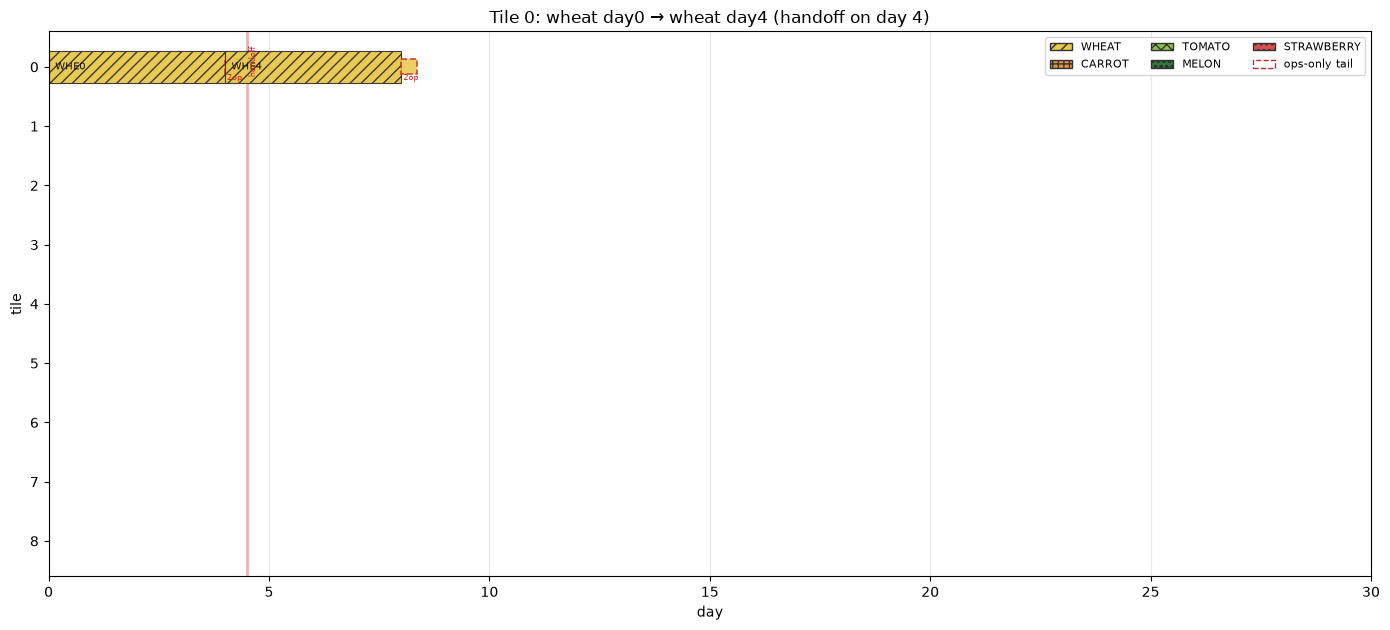

In [4]:
# forced back-to-back demo on tile 0 (shows handoff on day 4)
demo = [
    next(s for s in _build_candidates({0}, 0, PLAN_HORIZON, OPS_HORIZON, PRICES) if s["crop"] == "WHEAT" and s["plant_day"] == 0),
    next(s for s in _build_candidates({0}, 0, PLAN_HORIZON, OPS_HORIZON, PRICES) if s["crop"] == "WHEAT" and s["plant_day"] == 4),
]
gantt(demo, title="Tile 0: wheat day0 → wheat day4 (handoff on day 4)")

[planner] day=0 status=OPTIMAL candidates=954 selected=40 source=cpsat obj=27475.0
placements: 40
{'tile': 0, 'crop': 'MELON', 'plant_day': 0}
{'tile': 0, 'crop': 'MELON', 'plant_day': 10}
{'tile': 0, 'crop': 'CARROT', 'plant_day': 20}
{'tile': 0, 'crop': 'CARROT', 'plant_day': 23}
{'tile': 0, 'crop': 'CARROT', 'plant_day': 26}
{'tile': 1, 'crop': 'CARROT', 'plant_day': 0}
{'tile': 1, 'crop': 'CARROT', 'plant_day': 3}
{'tile': 1, 'crop': 'MELON', 'plant_day': 6}
{'tile': 1, 'crop': 'MELON', 'plant_day': 16}
{'tile': 1, 'crop': 'CARROT', 'plant_day': 26}
{'tile': 2, 'crop': 'MELON', 'plant_day': 0}
{'tile': 2, 'crop': 'CARROT', 'plant_day': 10}
{'tile': 2, 'crop': 'CARROT', 'plant_day': 13}
{'tile': 2, 'crop': 'CARROT', 'plant_day': 16}
{'tile': 2, 'crop': 'MELON', 'plant_day': 19}
{'tile': 3, 'crop': 'MELON', 'plant_day': 1}
{'tile': 3, 'crop': 'MELON', 'plant_day': 11}
{'tile': 3, 'crop': 'WHEAT', 'plant_day': 21}
{'tile': 3, 'crop': 'WHEAT', 'plant_day': 25}
{'tile': 4, 'crop': 'MELO

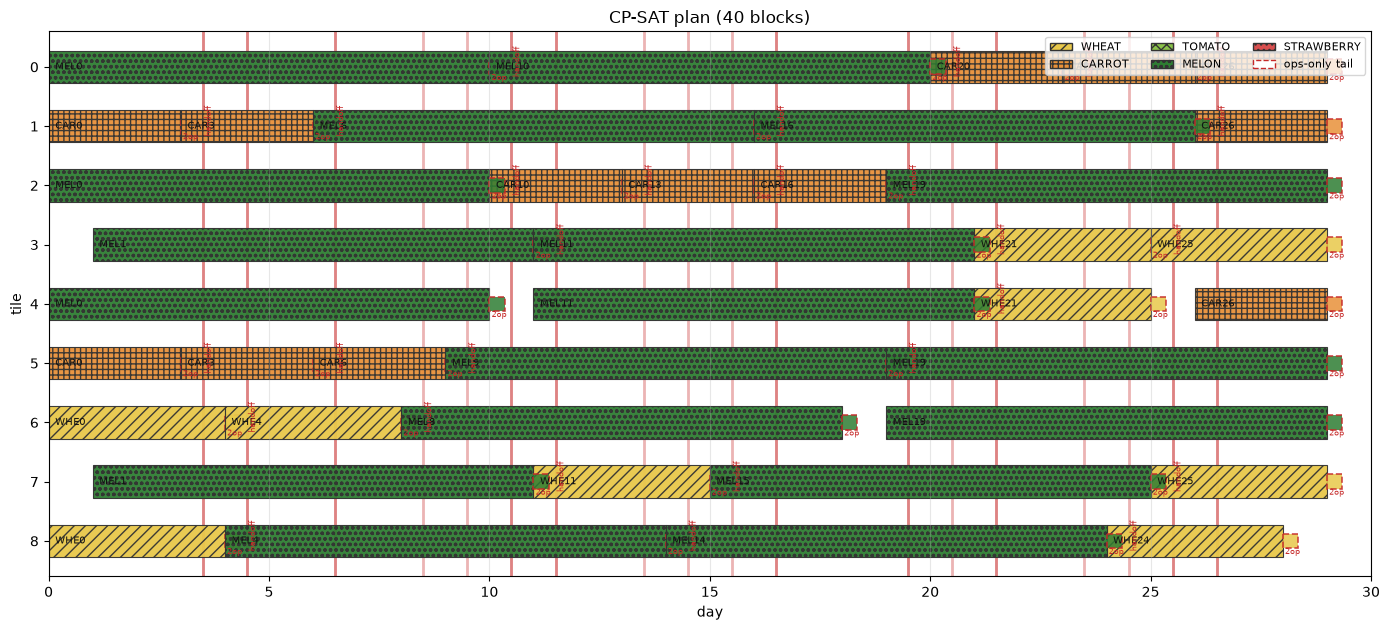

In [5]:
# planner solve on all 9 empty tiles (needs ortools)
plan = solve_plan(set(range(NUM_TILES)), [None] * NUM_TILES, current_day=0, prices=PRICES)
print(f"placements: {len(plan)}")
for p in sorted(plan, key=lambda x: (x["tile"], x["plant_day"])):
    print(p)

# reattach subset/ops from candidates for gantt
cands = {(s["tile"], s["crop"], s["plant_day"]): s for s in _build_candidates(set(range(NUM_TILES)), 0, PLAN_HORIZON, OPS_HORIZON, PRICES)}
selected = [cands[(p["tile"], p["crop"], p["plant_day"])] for p in plan if (p["tile"], p["crop"], p["plant_day"]) in cands]
gantt(selected, title=f"CP-SAT plan ({len(selected)} blocks)")